# Spatial hot spots with Gaussian Mixture Models

This notebook applies a Gaussian Mixture Model (GMM) to the spatial distribution of published taxi pickup locations.

Pickup coordinates are privacy-protected centroids, not exact addresses. Depending on data availability, a trip is located at either a Census Tract centroid or the much coarser Community Area centroid. Mixing both would create artificial peaks at the 77 Community Area centroids. The model therefore uses only Census-based pickup centroids. Repeated coordinates are retained because their frequency carries the demand information.

The candidate models are fitted to a fixed reservoir sample of eligible trips. Sampling trips rather than unique coordinates preserves their observed frequencies. No jitter is added to the published locations.

In [1]:
from pathlib import Path
import sys

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "run_config.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "notebooks"
if not (NOTEBOOK_DIR / "run_config.py").exists():
    raise FileNotFoundError("Could not locate notebooks/run_config.py")

sys.path.insert(0, str(NOTEBOOK_DIR))
from run_config import PATHS, RUN_MODE

pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

### Config

Pickup coordinates are projected from longitude and latitude (`EPSG:4326`) to NAD83 / UTM zone 16N (`EPSG:26916`). The projected coordinates are measured in metres and are suitable for interpreting spatial distances around Chicago.

In [2]:
SAMPLE_SIZE = 250_000
RANDOM_SEED = 42
SOURCE_CRS = "EPSG:4326"
METRIC_CRS = "EPSG:26916"

GMM_TAXI_PATH = PATHS.silver_taxi_census_tracts
REFERENCE_TAXI_PATH = PATHS.silver_taxi_community_areas_unfiltered
COMMUNITY_PATH = PATHS.silver_community_areas

for required_path in (GMM_TAXI_PATH, REFERENCE_TAXI_PATH, COMMUNITY_PATH):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

print(f"Run mode: {RUN_MODE}")
print(f"GMM taxi source: {GMM_TAXI_PATH}")
print(f"Reference population: {REFERENCE_TAXI_PATH}")
print(f"Community Areas (map and labels only): {COMMUNITY_PATH}")
print(f"Sample size: {SAMPLE_SIZE:,}; seed: {RANDOM_SEED}")

Run mode: full
GMM taxi source: /Users/moritz/Documents/Master Studium/Advanced Analytics and Application/assignment/Group-3-AAA/data/full/processed_data/silver_taxi_census_tracts.parquet
Reference population: /Users/moritz/Documents/Master Studium/Advanced Analytics and Application/assignment/Group-3-AAA/data/full/processed_data/silver_taxi_community_areas_UNFILTERED.parquet
Community Areas (map and labels only): /Users/moritz/Documents/Master Studium/Advanced Analytics and Application/assignment/Group-3-AAA/data/full/processed_data/silver_community_areas.geoparquet
Sample size: 250,000; seed: 42


### Coordinate provenance and GMM population

The GMM population comes from `silver_taxi_census_tracts`. Only projected pickup longitude and latitude enter the model. Census identifiers are used for data checks, while Community Area boundaries and names are added later for maps and labels. The full cleaned population is loaded separately to measure how the Census-centroid restriction changes the sample.

In [3]:
con = duckdb.connect()
gmm_taxi_file = GMM_TAXI_PATH.as_posix()
reference_taxi_file = REFERENCE_TAXI_PATH.as_posix()

source_summary = con.execute(
    """
    SELECT
        COUNT(*) AS total_cleaned_trips,
        COUNT(*) FILTER (
            WHERE pickup_centroid_latitude BETWEEN 41 AND 43
              AND pickup_centroid_longitude BETWEEN -89 AND -87
        ) AS trips_with_valid_pickup,
        COUNT(*) FILTER (
            WHERE pickup_from_census_tract
              AND pickup_centroid_latitude BETWEEN 41 AND 43
              AND pickup_centroid_longitude BETWEEN -89 AND -87
        ) AS gmm_eligible_trips,
        COUNT(*) FILTER (
            WHERE NOT pickup_from_census_tract
              AND pickup_centroid_latitude BETWEEN 41 AND 43
              AND pickup_centroid_longitude BETWEEN -89 AND -87
        ) AS community_centroid_trips,
        COUNT(DISTINCT (pickup_centroid_latitude, pickup_centroid_longitude)) FILTER (
            WHERE pickup_from_census_tract
              AND pickup_centroid_latitude BETWEEN 41 AND 43
              AND pickup_centroid_longitude BETWEEN -89 AND -87
        ) AS census_centroids,
        COUNT(DISTINCT (pickup_centroid_latitude, pickup_centroid_longitude)) FILTER (
            WHERE NOT pickup_from_census_tract
              AND pickup_centroid_latitude BETWEEN 41 AND 43
              AND pickup_centroid_longitude BETWEEN -89 AND -87
        ) AS community_area_centroids
    FROM read_parquet(?)
    """,
    [reference_taxi_file],
).df()

gmm_file_summary = con.execute(
    """
    SELECT
        COUNT(*) AS gmm_population_trips,
        COUNT(*) FILTER (
            WHERE pickup_centroid_latitude BETWEEN 41 AND 43
              AND pickup_centroid_longitude BETWEEN -89 AND -87
        ) AS trips_with_valid_pickup,
        COUNT(*) FILTER (WHERE pickup_from_census_tract) AS census_flagged_trips,
        COUNT(DISTINCT pickup_census_tract_source) AS census_source_ids,
        COUNT(DISTINCT (pickup_centroid_latitude, pickup_centroid_longitude)) AS census_centroids,
        COUNT(*) FILTER (
            WHERE pickup_census_tract_source IS NULL
               OR pickup_centroid_latitude IS NULL
               OR pickup_centroid_longitude IS NULL
        ) AS incomplete_rows
    FROM read_parquet(?)
    """,
    [gmm_taxi_file],
).df()

coordinate_source_summary = con.execute(
    """
    SELECT
        CASE
            WHEN pickup_from_census_tract THEN 'Census-based centroid: retained'
            ELSE 'Community Area centroid: excluded'
        END AS coordinate_source,
        COUNT(*) AS trips,
        COUNT(DISTINCT (pickup_centroid_latitude, pickup_centroid_longitude)) AS coordinates,
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS trip_share_pct
    FROM read_parquet(?)
    WHERE pickup_centroid_latitude BETWEEN 41 AND 43
      AND pickup_centroid_longitude BETWEEN -89 AND -87
    GROUP BY 1
    ORDER BY trips DESC
    """,
    [reference_taxi_file],
).df()

summary_row = source_summary.iloc[0]
gmm_row = gmm_file_summary.iloc[0]
assert summary_row.gmm_eligible_trips + summary_row.community_centroid_trips == summary_row.trips_with_valid_pickup
assert gmm_row.gmm_population_trips == summary_row.gmm_eligible_trips
assert gmm_row.gmm_population_trips == gmm_row.trips_with_valid_pickup
assert gmm_row.gmm_population_trips == gmm_row.census_flagged_trips
assert gmm_row.census_source_ids == gmm_row.census_centroids
assert gmm_row.incomplete_rows == 0
assert gmm_row.gmm_population_trips >= SAMPLE_SIZE
assert summary_row.community_area_centroids <= 77

display(gmm_file_summary.T.rename(columns={0: "value"}))
display(source_summary.T.rename(columns={0: "value"}))
display(coordinate_source_summary.round(3))

,value
gmm_population_trips,6049435
trips_with_valid_pickup,6049435
census_flagged_trips,6049435
census_source_ids,469
census_centroids,469
incomplete_rows,0


,value
total_cleaned_trips,13386706
trips_with_valid_pickup,13386706
gmm_eligible_trips,6049435
community_centroid_trips,7337271
census_centroids,469
community_area_centroids,77


,coordinate_source,trips,coordinates,trip_share_pct
0,Community Area centroid: excluded,7337271,77,54.810
1,Census-based centroid: retained,6049435,469,45.190


In [4]:
sample_query = f"""
    SELECT *
    FROM (
        SELECT
            trip_id,
            trip_start_timestamp,
            pickup_centroid_latitude AS pickup_latitude,
            pickup_centroid_longitude AS pickup_longitude
        FROM read_parquet(?)
        WHERE pickup_centroid_latitude BETWEEN 41 AND 43
          AND pickup_centroid_longitude BETWEEN -89 AND -87
    )
    USING SAMPLE {SAMPLE_SIZE} ROWS (reservoir, {RANDOM_SEED})
"""

pickup_sample = con.execute(sample_query, [gmm_taxi_file]).df()

assert len(pickup_sample) == SAMPLE_SIZE
assert pickup_sample[["pickup_latitude", "pickup_longitude"]].notna().all().all()

# A compact fingerprint makes accidental changes to the sample visible.
sample_hashes = pd.util.hash_pandas_object(
    pickup_sample.sort_values("trip_id", kind="stable")[
        ["trip_id", "pickup_latitude", "pickup_longitude"]
    ],
    index=False,
)
sample_fingerprint = f"{int(sample_hashes.sum()):016x}"

sample_summary = pd.Series({
    "sampled_trips": len(pickup_sample),
    "distinct_published_pickups": len(
        pickup_sample[["pickup_latitude", "pickup_longitude"]].drop_duplicates()
    ),
    "share_at_repeated_coordinates": 1 - (
        len(pickup_sample[["pickup_latitude", "pickup_longitude"]].drop_duplicates())
        / len(pickup_sample)
    ),
    "sample_fingerprint": sample_fingerprint,
})
sample_summary.to_frame("value")

,value
sampled_trips,250000
distinct_published_pickups,238
share_at_repeated_coordinates,0.999
sample_fingerprint,21946dd7f4f3945c


Most rows share their coordinate with other trips because locations are published as centroids. Removing these repetitions would remove demand information; spreading them artificially would imply precision that is not present in the data.

### Population and sample representativeness

Two checks are used. Community Area demand shares are compared between the Census-centroid subset and the complete cleaned population. The 250,000-trip reservoir sample is then compared with all eligible trips at coordinate level. Coordinates not drawn into the sample remain in this comparison with a count of zero.

In [5]:
eligible_coordinate_distribution = con.execute(
    """
    WITH coordinate_counts AS (
        SELECT
            pickup_centroid_latitude AS pickup_latitude,
            pickup_centroid_longitude AS pickup_longitude,
            COUNT(*) AS full_trip_count
        FROM read_parquet(?)
        WHERE pickup_centroid_latitude BETWEEN 41 AND 43
          AND pickup_centroid_longitude BETWEEN -89 AND -87
        GROUP BY 1, 2
    )
    SELECT
        pickup_latitude,
        pickup_longitude,
        full_trip_count,
        full_trip_count::DOUBLE / SUM(full_trip_count) OVER () AS full_trip_share
    FROM coordinate_counts
    ORDER BY full_trip_count DESC
    """,
    [gmm_taxi_file],
).df()

sample_coordinate_distribution = (
    pickup_sample
    .groupby(["pickup_latitude", "pickup_longitude"], as_index=False)
    .size()
    .rename(columns={"size": "sample_trip_count"})
)
sample_coordinate_distribution["sample_trip_share"] = (
    sample_coordinate_distribution["sample_trip_count"] / len(pickup_sample)
)

coordinate_comparison = eligible_coordinate_distribution.merge(
    sample_coordinate_distribution,
    on=["pickup_latitude", "pickup_longitude"],
    how="left",
)
coordinate_comparison[["sample_trip_count", "sample_trip_share"]] = (
    coordinate_comparison[["sample_trip_count", "sample_trip_share"]].fillna(0)
)
coordinate_comparison["sample_trip_count"] = (
    coordinate_comparison["sample_trip_count"].astype("int64")
)
coordinate_comparison["share_difference"] = (
    coordinate_comparison["sample_trip_share"]
    - coordinate_comparison["full_trip_share"]
)
coordinate_comparison["observed_in_sample"] = (
    coordinate_comparison["sample_trip_count"] > 0
)

assert len(coordinate_comparison) == int(source_summary.loc[0, "census_centroids"])
assert coordinate_comparison["full_trip_count"].sum() == int(
    source_summary.loc[0, "gmm_eligible_trips"]
)
assert coordinate_comparison["sample_trip_count"].sum() == SAMPLE_SIZE
assert np.isclose(coordinate_comparison["full_trip_share"].sum(), 1)
assert np.isclose(coordinate_comparison["sample_trip_share"].sum(), 1)

community_population_comparison = con.execute(
    """
    SELECT
        pickup_community_area AS community_area,
        COUNT(*) AS all_trips,
        COUNT(*) FILTER (WHERE pickup_from_census_tract) AS eligible_trips,
        COUNT(*)::DOUBLE / SUM(COUNT(*)) OVER () AS all_trip_share,
        COUNT(*) FILTER (WHERE pickup_from_census_tract)::DOUBLE
            / SUM(COUNT(*) FILTER (WHERE pickup_from_census_tract)) OVER () AS eligible_trip_share
    FROM read_parquet(?)
    WHERE pickup_centroid_latitude BETWEEN 41 AND 43
      AND pickup_centroid_longitude BETWEEN -89 AND -87
    GROUP BY 1
    ORDER BY all_trips DESC
    """,
    [reference_taxi_file],
).df()
community_population_comparison["share_difference"] = (
    community_population_comparison.eligible_trip_share
    - community_population_comparison.all_trip_share
)

display(coordinate_comparison.head(15))
display(community_population_comparison.head(15).round(4))

,pickup_latitude,pickup_longitude,full_trip_count,full_trip_share,sample_trip_count,sample_trip_share,share_difference,observed_in_sample
0,41.979,-87.903,1344621,0.222,55207,0.221,-0.001,True
1,41.881,-87.633,647889,0.107,26896,0.108,0.000,True
2,41.885,-87.621,636244,0.105,26565,0.106,0.001,True
3,41.879,-87.643,510243,0.084,21131,0.085,0.000,True
4,41.893,-87.626,354838,0.059,14444,0.058,-0.001,True
5,41.895,-87.620,266424,0.044,11166,0.045,0.001,True
6,41.859,-87.617,225333,0.037,9339,0.037,0.000,True
7,41.885,-87.643,211660,0.035,8585,0.034,-0.001,True
8,41.891,-87.619,204330,0.034,8532,0.034,0.000,True
9,41.786,-87.751,179803,0.030,7519,0.030,0.000,True


,community_area,all_trips,eligible_trips,all_trip_share,eligible_trip_share,share_difference
0,8,3058013,1720160,0.228,0.284,0.056
1,76,2859309,1344720,0.214,0.222,0.009
2,32,2228422,1567701,0.167,0.259,0.093
3,28,1376721,823553,0.103,0.136,0.033
4,33,471855,295541,0.035,0.049,0.014
5,6,457724,38056,0.034,0.006,-0.028
6,56,389363,179872,0.029,0.030,0.001
7,7,301512,30081,0.022,0.005,-0.018
8,3,226149,15821,0.017,0.003,-0.014
9,77,156719,2849,0.012,0.001,-0.011


In [6]:
absolute_share_error = coordinate_comparison["share_difference"].abs()
community_share_error = community_population_comparison["share_difference"].abs()
distribution_metrics = pd.Series({
    "gmm_population_share_pct": 100 * (
        source_summary.loc[0, "gmm_eligible_trips"]
        / source_summary.loc[0, "total_cleaned_trips"]
    ),
    "community_share_pearson_correlation": community_population_comparison[
        ["all_trip_share", "eligible_trip_share"]
    ].corr(method="pearson").iloc[0, 1],
    "community_share_total_variation_pct": 100 * 0.5 * community_share_error.sum(),
    "community_share_max_difference_pp": 100 * community_share_error.max(),
    "eligible_coordinates": len(coordinate_comparison),
    "coordinates_observed_in_sample": int(
        coordinate_comparison["observed_in_sample"].sum()
    ),
    "coordinate_coverage_pct": 100 * coordinate_comparison["observed_in_sample"].mean(),
    "eligible_demand_share_covered_pct": 100 * coordinate_comparison.loc[
        coordinate_comparison["observed_in_sample"], "full_trip_share"
    ].sum(),
    "pearson_share_correlation": coordinate_comparison[
        ["full_trip_share", "sample_trip_share"]
    ].corr(method="pearson").iloc[0, 1],
    "spearman_share_correlation": coordinate_comparison[
        ["full_trip_share", "sample_trip_share"]
    ].corr(method="spearman").iloc[0, 1],
    "mean_absolute_error_percentage_points": 100 * absolute_share_error.mean(),
    "maximum_absolute_error_percentage_points": 100 * absolute_share_error.max(),
    "total_variation_distance_pct": 100 * 0.5 * absolute_share_error.sum(),
})
distribution_metrics.to_frame("value").style.format({"value": "{:.6f}"})

,value
gmm_population_share_pct,45.189870
community_share_pearson_correlation,0.982497
community_share_total_variation_pct,20.484131
community_share_max_difference_pp,9.268304
eligible_coordinates,469.000000
coordinates_observed_in_sample,238.000000
coordinate_coverage_pct,50.746269
eligible_demand_share_covered_pct,99.972774
pearson_share_correlation,0.999967
spearman_share_correlation,0.853301


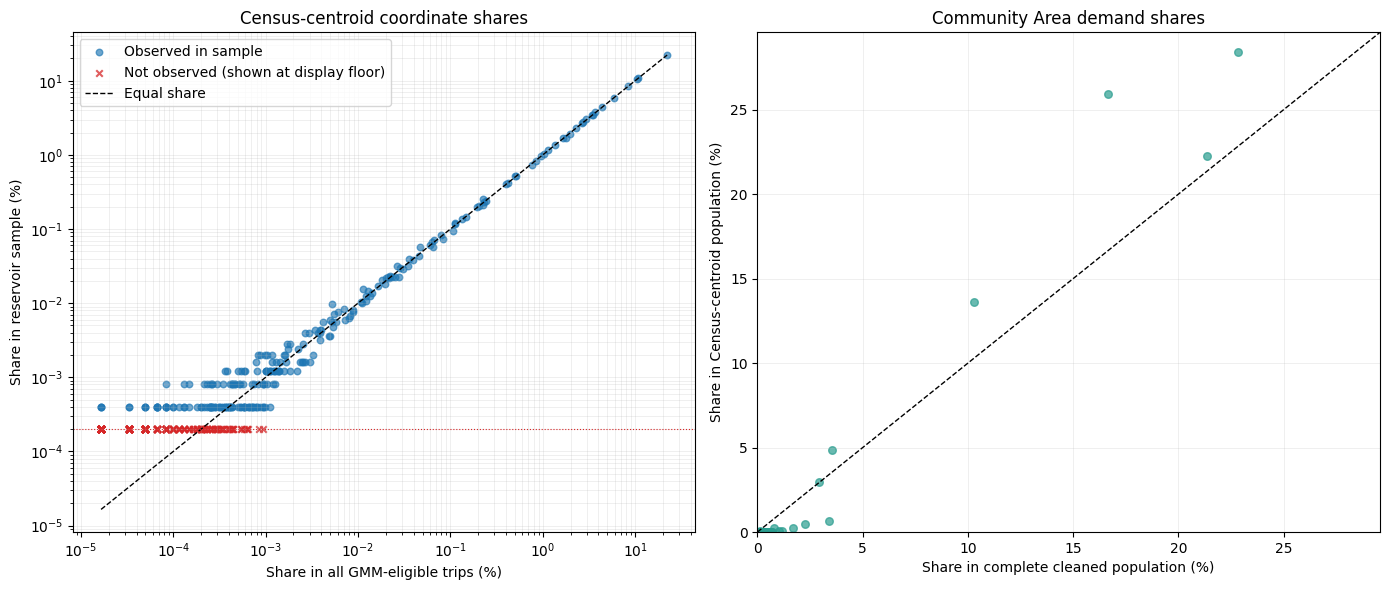

In [7]:
observed_mask = coordinate_comparison["observed_in_sample"]
full_share_pct = 100 * coordinate_comparison["full_trip_share"]
sample_share_pct = 100 * coordinate_comparison["sample_trip_share"]
display_floor_pct = 0.5 * 100 / SAMPLE_SIZE
sample_share_for_plot = sample_share_pct.mask(~observed_mask, display_floor_pct)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(
    full_share_pct[observed_mask],
    sample_share_pct[observed_mask],
    s=22,
    alpha=0.65,
    color="#1f77b4",
    label="Observed in sample",
)
axes[0].scatter(
    full_share_pct[~observed_mask],
    sample_share_for_plot[~observed_mask],
    s=22,
    alpha=0.75,
    color="#d62728",
    marker="x",
    label="Not observed (shown at display floor)",
)

line_min = full_share_pct.min()
line_max = max(full_share_pct.max(), sample_share_pct.max())
axes[0].plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    color="black",
    linewidth=1,
    label="Equal share",
)
axes[0].axhline(
    display_floor_pct,
    color="#d62728",
    linestyle=":",
    linewidth=0.8,
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Share in all GMM-eligible trips (%)")
axes[0].set_ylabel("Share in reservoir sample (%)")
axes[0].set_title("Census-centroid coordinate shares")
axes[0].grid(True, which="both", linewidth=0.4, alpha=0.35)
axes[0].legend()

all_community_share_pct = 100 * community_population_comparison.all_trip_share
eligible_community_share_pct = 100 * community_population_comparison.eligible_trip_share
community_limit = max(all_community_share_pct.max(), eligible_community_share_pct.max()) * 1.04
axes[1].scatter(
    all_community_share_pct,
    eligible_community_share_pct,
    s=30,
    alpha=0.7,
    color="#2a9d8f",
)
axes[1].plot([0, community_limit], [0, community_limit], "--", color="black", linewidth=1)
axes[1].set(
    xlim=(0, community_limit),
    ylim=(0, community_limit),
    xlabel="Share in complete cleaned population (%)",
    ylabel="Share in Census-centroid population (%)",
    title="Community Area demand shares",
)
axes[1].grid(True, linewidth=0.4, alpha=0.35)
plt.tight_layout()
plt.show()

The eligible subset contains 6,049,435 trips, equal to 45.19% of the cleaned population. Community Area shares in both populations are strongly correlated (Pearson correlation 0.9825), but their total variation distance is 20.48% and the largest difference is 9.27 percentage points. Excluding Community Area centroids avoids coarse artificial peaks, but it also changes the spatial demand distribution.

The reservoir sample contains 238 of the 469 Census centroids and covers 99.973% of eligible demand. Its coordinate shares closely match the eligible population (Pearson correlation 0.999967; total variation distance 0.572%). The missing coordinates are rare, but the sample does not represent every published centroid.

### Project pickup locations and construct the GMM input

`X_gmm` contains projected easting and northing in kilometres. No time variables, trip attributes, H3 cells or Census identifiers enter the model.

In [8]:
pickup_gdf = gpd.GeoDataFrame(
    pickup_sample.copy(),
    geometry=gpd.points_from_xy(
        pickup_sample["pickup_longitude"],
        pickup_sample["pickup_latitude"],
        crs=SOURCE_CRS,
    ),
).to_crs(METRIC_CRS)

pickup_gdf["pickup_x_km"] = pickup_gdf.geometry.x / 1_000
pickup_gdf["pickup_y_km"] = pickup_gdf.geometry.y / 1_000

X_gmm = pickup_gdf[["pickup_x_km", "pickup_y_km"]].to_numpy(dtype=np.float64)

assert X_gmm.shape == (SAMPLE_SIZE, 2)
assert np.isfinite(X_gmm).all()

projection_summary = pd.DataFrame(
    {
        "minimum": X_gmm.min(axis=0),
        "mean": X_gmm.mean(axis=0),
        "maximum": X_gmm.max(axis=0),
        "standard_deviation": X_gmm.std(axis=0),
    },
    index=["pickup_x_km", "pickup_y_km"],
)
projection_summary

,minimum,mean,maximum,standard_deviation
pickup_x_km,425.188,442.524,455.800,9.423
pickup_y_km,"4,612.740","4,639.285","4,652.350",5.140


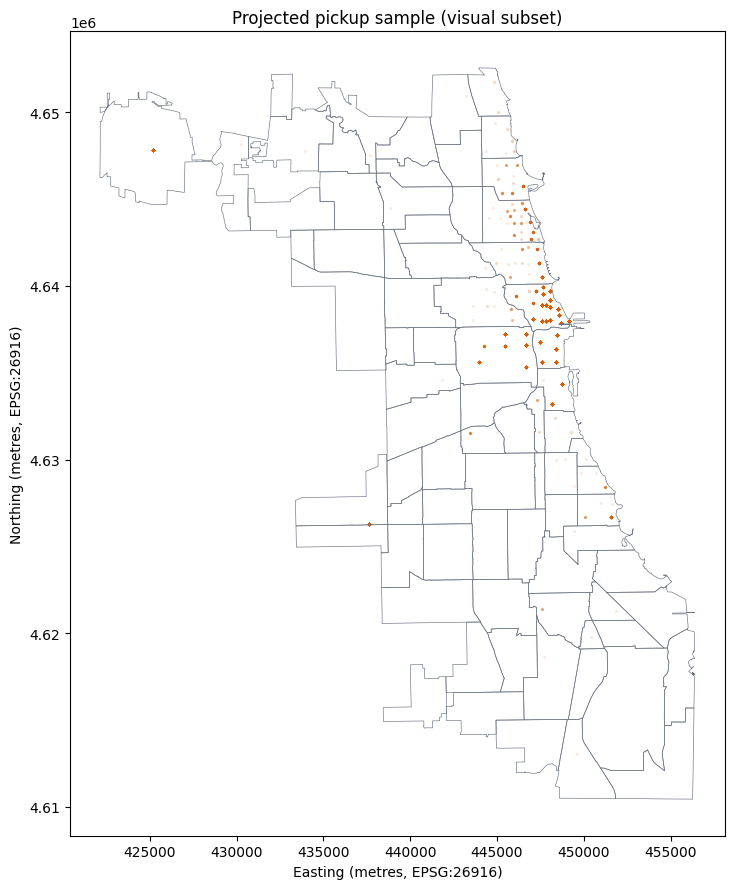

In [9]:
community_areas = gpd.read_parquet(COMMUNITY_PATH).to_crs(METRIC_CRS)
plot_points = pickup_gdf.sample(
    n=min(30_000, len(pickup_gdf)),
    random_state=RANDOM_SEED,
)

fig, ax = plt.subplots(figsize=(8, 9))
community_areas.boundary.plot(ax=ax, color="#6b7280", linewidth=0.45)
plot_points.plot(
    ax=ax,
    color="#d95f02",
    markersize=2,
    alpha=0.08,
    rasterized=True,
)
ax.set_title("Projected pickup sample (visual subset)")
ax.set_xlabel("Easting (metres, EPSG:26916)")
ax.set_ylabel("Northing (metres, EPSG:26916)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Train and compare candidate GMMs

Candidate models cover K=2–30 and the spherical, diagonal, tied and full covariance specifications. Every fit starts from K-Means initialization.

With coordinates in kilometres, `reg_covar=0.0001` sets a numerical standard-deviation floor of 0.01 km (10 m). Components near this floor are treated as collapsed rather than accepted as meaningful hot spots.

In [10]:
from time import perf_counter
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.mixture import GaussianMixture
from shapely.geometry import Point

COMPONENT_RANGE = range(2, 31)
COVARIANCE_TYPES = ("spherical", "diag", "tied", "full")
GMM_N_INIT = 5
GMM_MAX_ITER = 300
GMM_TOL = 1e-3
GMM_REG_COVAR = 1e-4  # km²; sqrt = 0.01 km = 10 m
SPATIAL_MIN_STD_KM = 0.05  # 50 m near-collapse screen for published centroids
MIN_COMPONENT_WEIGHT = 0.0025  # 0.25%; at least 625 of 250,000 sampled trips

print(
    f"Candidate fits: {len(COMPONENT_RANGE) * len(COVARIANCE_TYPES)} "
    f"({len(COMPONENT_RANGE)} K values × {len(COVARIANCE_TYPES)} covariance types)"
)
print(
    f"Plausibility thresholds: minimum std = {SPATIAL_MIN_STD_KM:.2f} km; "
    f"minimum component weight = {MIN_COMPONENT_WEIGHT:.2%}"
)

Candidate fits: 116 (29 K values × 4 covariance types)
Plausibility thresholds: minimum std = 0.05 km; minimum component weight = 0.25%


In [11]:
def covariance_matrices(model):
    """Return one 2x2 covariance matrix per GMM component."""
    k = model.n_components
    if model.covariance_type == "full":
        return model.covariances_
    if model.covariance_type == "tied":
        return np.repeat(model.covariances_[None, :, :], k, axis=0)
    if model.covariance_type == "diag":
        return np.array([np.diag(values) for values in model.covariances_])
    if model.covariance_type == "spherical":
        return np.array([np.eye(2) * value for value in model.covariances_])
    raise ValueError(f"Unsupported covariance type: {model.covariance_type}")


def gmm_parameter_count(k, covariance_type, dimensions=2):
    weights = k - 1
    means = k * dimensions
    if covariance_type == "spherical":
        covariance = k
    elif covariance_type == "diag":
        covariance = k * dimensions
    elif covariance_type == "tied":
        covariance = dimensions * (dimensions + 1) // 2
    elif covariance_type == "full":
        covariance = k * dimensions * (dimensions + 1) // 2
    else:
        raise ValueError(covariance_type)
    return weights + means + covariance


candidate_models = {}
candidate_records = []

for covariance_type in COVARIANCE_TYPES:
    for k in COMPONENT_RANGE:
        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            init_params="kmeans",
            n_init=GMM_N_INIT,
            max_iter=GMM_MAX_ITER,
            tol=GMM_TOL,
            reg_covar=GMM_REG_COVAR,
            random_state=RANDOM_SEED,
        )

        started = perf_counter()
        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter("always", ConvergenceWarning)
            model.fit(X_gmm)
        fit_seconds = perf_counter() - started

        covariance_array = covariance_matrices(model)
        eigenvalues = np.linalg.eigvalsh(covariance_array)
        component_min_std_km = np.sqrt(eigenvalues.min(axis=1))
        component_max_std_km = np.sqrt(eigenvalues.max(axis=1))
        key = (covariance_type, k)
        candidate_models[key] = model
        candidate_records.append({
            "covariance_type": covariance_type,
            "n_components": k,
            "n_parameters": gmm_parameter_count(k, covariance_type),
            "converged": bool(model.converged_),
            "convergence_warning": any(
                issubclass(item.category, ConvergenceWarning) for item in caught_warnings
            ),
            "n_iter": model.n_iter_,
            "fit_seconds": fit_seconds,
            "mean_log_likelihood": model.score(X_gmm),
            "aic": model.aic(X_gmm),
            "bic": model.bic(X_gmm),
            "min_component_weight": model.weights_.min(),
            "min_component_std_km": component_min_std_km.min(),
            "max_component_std_km": component_max_std_km.max(),
            "components_at_variance_floor": int(
                np.sum(component_min_std_km <= np.sqrt(GMM_REG_COVAR) * 1.01)
            ),
            "components_below_50m_std": int(
                np.sum(component_min_std_km < SPATIAL_MIN_STD_KM)
            ),
        })
    print(f"Finished covariance_type={covariance_type!r}")

candidate_results = pd.DataFrame(candidate_records)
candidate_results["aic_per_trip"] = candidate_results["aic"] / len(X_gmm)
candidate_results["bic_per_trip"] = candidate_results["bic"] / len(X_gmm)
candidate_results["delta_aic"] = candidate_results["aic"] - candidate_results["aic"].min()
candidate_results["delta_bic"] = candidate_results["bic"] - candidate_results["bic"].min()
candidate_results.sort_values(["bic", "aic"]).head(12)

Finished covariance_type='spherical'


Finished covariance_type='diag'


Finished covariance_type='tied'


Finished covariance_type='full'


,covariance_type,n_components,n_parameters,converged,convergence_warning,n_iter,fit_seconds,mean_log_likelihood,aic,bic,min_component_weight,min_component_std_km,max_component_std_km,components_at_variance_floor,components_below_50m_std,aic_per_trip,bic_per_trip,delta_aic,delta_bic
115,full,30,179,True,False,7,16.659,3.918,"-1,958,875.187","-1,957,008.357",0.000,0.010,6.107,22,23,-7.836,-7.828,0.000,0.000
57,diag,30,149,True,False,11,6.819,3.859,"-1,929,433.523","-1,927,879.569",0.000,0.010,5.946,19,20,-7.718,-7.712,"29,441.664","29,128.788"
114,full,29,173,True,False,12,14.895,3.845,"-1,922,125.375","-1,920,321.121",0.000,0.010,8.700,22,23,-7.689,-7.681,"36,749.811","36,687.236"
56,diag,29,144,True,False,36,6.924,3.826,"-1,912,617.742","-1,911,115.935",0.000,0.010,5.329,19,21,-7.650,-7.644,"46,257.445","45,892.422"
26,spherical,28,111,True,False,59,21.580,3.787,"-1,893,518.321","-1,892,360.678",0.000,0.010,2.856,19,20,-7.574,-7.569,"65,356.866","64,647.679"
113,full,28,167,True,False,11,14.869,3.746,"-1,872,438.602","-1,870,696.923",0.000,0.010,10.702,23,24,-7.490,-7.483,"86,436.584","86,311.434"
28,spherical,30,119,True,False,39,11.210,3.731,"-1,865,424.707","-1,864,183.630",0.000,0.010,3.950,15,18,-7.462,-7.457,"93,450.480","92,824.727"
55,diag,28,139,True,False,15,7.245,3.701,"-1,850,321.786","-1,848,872.125",0.000,0.010,6.142,16,20,-7.401,-7.395,"108,553.400","108,136.232"
110,full,25,149,True,False,8,12.911,3.683,"-1,841,408.246","-1,839,854.293",0.000,0.010,6.195,18,19,-7.366,-7.359,"117,466.940","117,154.064"
52,diag,25,124,True,False,22,14.503,3.617,"-1,808,300.797","-1,807,007.574",0.000,0.009,5.804,16,18,-7.233,-7.228,"150,574.390","150,000.783"


### AIC, BIC and convergence

AIC and BIC are calculated on the same 250,000 trips; lower values indicate a better fit after penalizing model complexity. Values are divided by the sample size for readability. Minimum component weight is shown because repeated centroids can make likelihood criteria favour very small components.

In [12]:
convergence_summary = (
    candidate_results
    .groupby("covariance_type", as_index=False)
    .agg(
        fitted_models=("n_components", "size"),
        converged_models=("converged", "sum"),
        maximum_iterations=("n_iter", "max"),
        total_fit_seconds=("fit_seconds", "sum"),
        models_with_floor_components=("components_at_variance_floor", lambda s: (s > 0).sum()),
        models_with_below_50m_components=("components_below_50m_std", lambda s: (s > 0).sum()),
        models_below_minimum_weight=("min_component_weight", lambda s: (s < MIN_COMPONENT_WEIGHT).sum()),
    )
)
convergence_summary

,covariance_type,fitted_models,converged_models,maximum_iterations,total_fit_seconds,models_with_floor_components,models_with_below_50m_components,models_below_minimum_weight
0,diag,29,29,65,185.995,29,29,14
1,full,29,29,24,244.488,29,29,14
2,spherical,29,29,74,245.905,29,29,12
3,tied,29,29,35,128.867,0,0,14


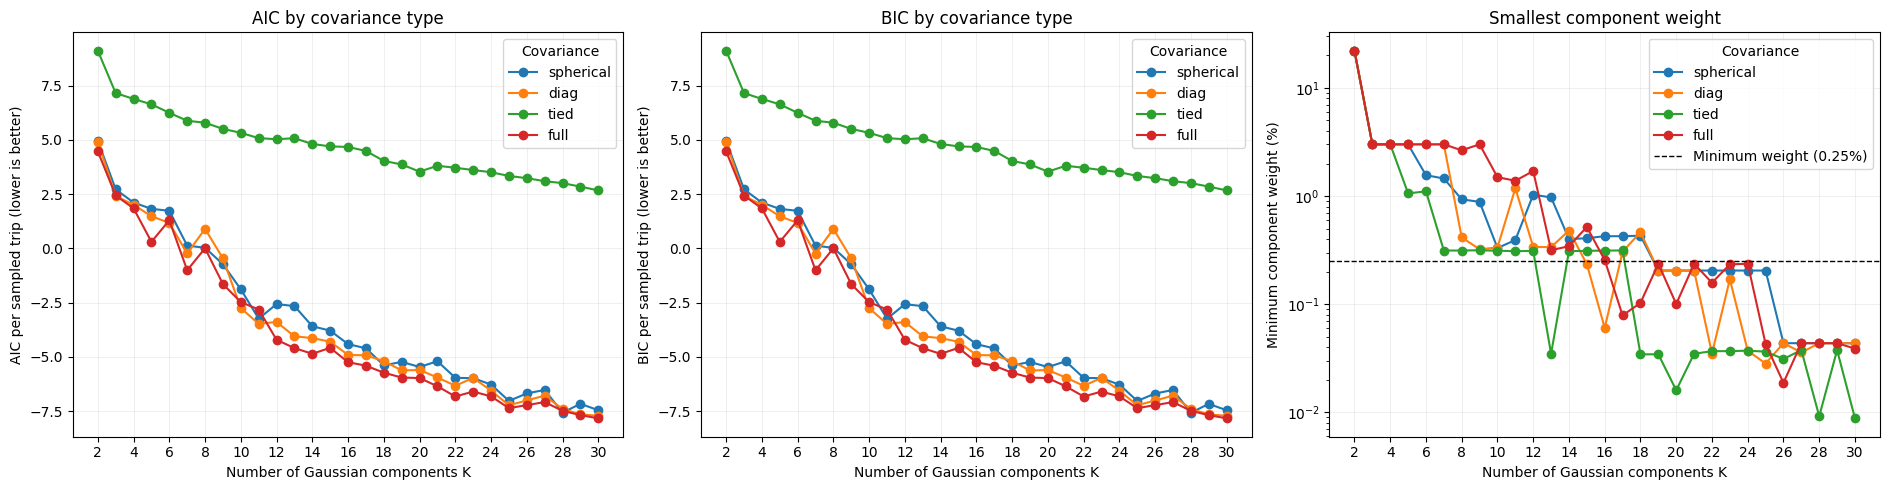

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharex=True)
for covariance_type in COVARIANCE_TYPES:
    subset = candidate_results[candidate_results["covariance_type"] == covariance_type]
    axes[0].plot(
        subset["n_components"], subset["aic_per_trip"],
        marker="o", label=covariance_type,
    )
    axes[1].plot(
        subset["n_components"], subset["bic_per_trip"],
        marker="o", label=covariance_type,
    )
    axes[2].plot(
        subset["n_components"], 100 * subset["min_component_weight"],
        marker="o", label=covariance_type,
    )

axes[0].set_title("AIC by covariance type")
axes[0].set_ylabel("AIC per sampled trip (lower is better)")
axes[1].set_title("BIC by covariance type")
axes[1].set_ylabel("BIC per sampled trip (lower is better)")
axes[2].axhline(
    100 * MIN_COMPONENT_WEIGHT,
    color="black", linestyle="--", linewidth=1,
    label=f"Minimum weight ({MIN_COMPONENT_WEIGHT:.2%})",
)
axes[2].set_title("Smallest component weight")
axes[2].set_ylabel("Minimum component weight (%)")
axes[2].set_yscale("log")
for ax in axes:
    ax.set_xlabel("Number of Gaussian components K")
    ax.set_xticks(range(2, max(COMPONENT_RANGE) + 1, 2))
    ax.grid(True, linewidth=0.4, alpha=0.35)
    ax.legend(title="Covariance")
plt.tight_layout()
plt.show()

In [14]:
selection_columns = [
    "covariance_type", "n_components", "n_parameters",
    "converged", "n_iter", "aic_per_trip", "bic_per_trip",
    "delta_aic", "delta_bic", "min_component_weight",
    "min_component_std_km", "components_at_variance_floor",
    "components_below_50m_std",
]
candidate_results.sort_values("bic")[selection_columns].head(15)

,covariance_type,n_components,n_parameters,converged,n_iter,aic_per_trip,bic_per_trip,delta_aic,delta_bic,min_component_weight,min_component_std_km,components_at_variance_floor,components_below_50m_std
115,full,30,179,True,7,-7.836,-7.828,0.000,0.000,0.000,0.010,22,23
57,diag,30,149,True,11,-7.718,-7.712,"29,441.664","29,128.788",0.000,0.010,19,20
114,full,29,173,True,12,-7.689,-7.681,"36,749.811","36,687.236",0.000,0.010,22,23
56,diag,29,144,True,36,-7.650,-7.644,"46,257.445","45,892.422",0.000,0.010,19,21
26,spherical,28,111,True,59,-7.574,-7.569,"65,356.866","64,647.679",0.000,0.010,19,20
113,full,28,167,True,11,-7.490,-7.483,"86,436.584","86,311.434",0.000,0.010,23,24
28,spherical,30,119,True,39,-7.462,-7.457,"93,450.480","92,824.727",0.000,0.010,15,18
55,diag,28,139,True,15,-7.401,-7.395,"108,553.400","108,136.232",0.000,0.010,16,20
110,full,25,149,True,8,-7.366,-7.359,"117,466.940","117,154.064",0.000,0.010,18,19
52,diag,25,124,True,22,-7.233,-7.228,"150,574.390","150,000.783",0.000,0.009,16,18


### Select the best plausible candidate

The selection excludes models that fail to converge, contain a component narrower than 50 m, or assign less than 0.25% of the total weight to any component. The 50 m threshold separates spatial components from near-point fits at repeated centroids. The weight threshold corresponds to 625 trips in the sample. Among the remaining candidates, the model with the lowest BIC is selected. Community Area boundaries and labels play no role in this decision.

In [15]:
candidate_results["plausible_for_selection"] = (
    candidate_results["converged"]
    & ~candidate_results["convergence_warning"]
    & candidate_results["components_below_50m_std"].eq(0)
    & candidate_results["min_component_weight"].ge(MIN_COMPONENT_WEIGHT)
)

raw_bic_winner = candidate_results.loc[candidate_results["bic"].idxmin()]
plausible_candidates = candidate_results[candidate_results["plausible_for_selection"]].copy()
if plausible_candidates.empty:
    raise RuntimeError("No candidate passed the spatial plausibility safeguards.")

selected_result = plausible_candidates.loc[plausible_candidates["bic"].idxmin()]
selected_key = (
    selected_result["covariance_type"],
    int(selected_result["n_components"]),
)
selected_gmm = candidate_models[selected_key]

selection_comparison = pd.DataFrame([
    {"selection": "Raw BIC minimum", **raw_bic_winner.to_dict()},
    {"selection": "Selected plausible model", **selected_result.to_dict()},
])[[
    "selection", "covariance_type", "n_components", "n_parameters",
    "converged", "n_iter", "aic_per_trip", "bic_per_trip",
    "min_component_weight", "min_component_std_km",
    "components_at_variance_floor", "components_below_50m_std",
]]
selection_comparison

,selection,covariance_type,n_components,n_parameters,converged,n_iter,aic_per_trip,bic_per_trip,min_component_weight,min_component_std_km,components_at_variance_floor,components_below_50m_std
0,Raw BIC minimum,full,30,179,True,7,-7.836,-7.828,0.000,0.010,22,23
1,Selected plausible model,tied,17,53,True,5,4.489,4.492,0.003,0.162,0,0


In [16]:
plausible_ranking = plausible_candidates.sort_values("bic")[selection_columns].head(12)
plausible_ranking

,covariance_type,n_components,n_parameters,converged,n_iter,aic_per_trip,bic_per_trip,delta_aic,delta_bic,min_component_weight,min_component_std_km,components_at_variance_floor,components_below_50m_std
73,tied,17,53,True,5,4.489,4.492,"3,081,208.454","3,079,894.372",0.003,0.162,0,0
72,tied,16,50,True,13,4.673,4.675,"3,127,059.212","3,125,713.843",0.003,0.174,0,0
71,tied,15,47,True,9,4.700,4.702,"3,133,760.447","3,132,383.791",0.003,0.165,0,0
70,tied,14,44,True,14,4.811,4.812,"3,161,518.064","3,160,110.119",0.003,0.160,0,0
68,tied,12,38,True,12,5.030,5.031,"3,216,260.140","3,214,789.621",0.003,0.174,0,0
67,tied,11,35,True,18,5.079,5.081,"3,228,732.411","3,227,230.604",0.003,0.170,0,0
66,tied,10,32,True,10,5.325,5.327,"3,290,177.947","3,288,644.853",0.003,0.236,0,0
65,tied,9,29,True,9,5.504,5.506,"3,334,959.548","3,333,395.165",0.003,0.317,0,0
64,tied,8,26,True,4,5.790,5.791,"3,406,341.774","3,404,746.104",0.003,0.424,0,0
63,tied,7,23,True,7,5.880,5.881,"3,428,935.054","3,427,308.096",0.003,0.427,0,0


All 116 candidate models converge. The full-covariance model with K=30 has the lowest unfiltered BIC, but 23 components are narrower than 50 m, 22 reach the 10 m numerical floor, and the smallest component falls below the weight threshold. It is therefore fitting repeated centroids too closely and is rejected.

Every spherical, diagonal and full-covariance candidate contains at least one component below 50 m. The lowest BIC among the remaining models belongs to the tied-covariance model with K=17. It converges after five iterations, uses 53 parameters, has a minimum weight of 0.314%, and a minimum component standard deviation of 0.162 km. K=18 improves BIC but introduces a component below the weight threshold. Under these rules, K=17 is selected. The number is specific to this model and these thresholds, not a count of objectively defined physical hot spots.

### Selected components

Components are numbered by descending weight. Their means are assigned a Community Area label for orientation. The 95% ellipse is a probability contour, not a cluster boundary. Ellipse area describes spatial spread; weighted density at the mean combines spread and component weight.

In [17]:
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from shapely import contains_xy

CHI2_95_DF2 = 5.991464547
selected_covariances = covariance_matrices(selected_gmm)
component_order = np.argsort(selected_gmm.weights_)[::-1]
gmm_population_trips = int(source_summary.loc[0, "gmm_eligible_trips"])

component_records = []
for display_id, model_index in enumerate(component_order, start=1):
    covariance = selected_covariances[model_index]
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    eigen_order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[eigen_order]
    eigenvectors = eigenvectors[:, eigen_order]
    major_std_km, minor_std_km = np.sqrt(eigenvalues)
    angle_deg = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    ellipse_area_95_km2 = np.pi * CHI2_95_DF2 * np.sqrt(np.linalg.det(covariance))
    weight = selected_gmm.weights_[model_index]
    component_peak_density = weight / (2 * np.pi * np.sqrt(np.linalg.det(covariance)))
    mean_x_km, mean_y_km = selected_gmm.means_[model_index]

    component_records.append({
        "component": display_id,
        "model_index": model_index,
        "weight": weight,
        "sample_trips_effective": weight * len(X_gmm),
        "eligible_trips_estimated": weight * gmm_population_trips,
        "mean_x_km": mean_x_km,
        "mean_y_km": mean_y_km,
        "major_std_km": major_std_km,
        "minor_std_km": minor_std_km,
        "axis_ratio": major_std_km / minor_std_km,
        "angle_deg": angle_deg,
        "ellipse_area_95_km2": ellipse_area_95_km2,
        "weighted_peak_density_per_km2": component_peak_density,
    })

component_table = pd.DataFrame(component_records)
component_points = gpd.GeoDataFrame(
    component_table.copy(),
    geometry=gpd.points_from_xy(
        component_table["mean_x_km"] * 1_000,
        component_table["mean_y_km"] * 1_000,
    ),
    crs=METRIC_CRS,
)
component_points = gpd.sjoin(
    component_points,
    community_areas[["COMMUNITY", "geometry"]],
    how="left",
    predicate="within",
).drop_duplicates(subset="component")
component_table = (
    component_table
    .merge(component_points[["component", "COMMUNITY"]], on="component", how="left")
    .rename(columns={"COMMUNITY": "community_area_at_mean"})
)

component_display_columns = [
    "component", "community_area_at_mean", "weight",
    "sample_trips_effective", "eligible_trips_estimated",
    "major_std_km", "minor_std_km", "axis_ratio",
    "ellipse_area_95_km2", "weighted_peak_density_per_km2",
]
component_table[component_display_columns]

,component,community_area_at_mean,weight,sample_trips_effective,eligible_trips_estimated,major_std_km,minor_std_km,axis_ratio,ellipse_area_95_km2,weighted_peak_density_per_km2
0,1,OHARE,0.221,"55,214.000","1,336,054.016",0.356,0.162,2.193,1.085,0.610
1,2,NEAR WEST SIDE,0.121,"30,200.019","730,772.200",0.356,0.162,2.193,1.085,0.333
2,3,LOOP,0.119,"29,810.743","721,352.604",0.356,0.162,2.193,1.085,0.329
3,4,LOOP,0.112,"28,008.903","677,752.157",0.356,0.162,2.193,1.085,0.309
4,5,NEAR NORTH SIDE,0.111,"27,821.686","673,221.914",0.356,0.162,2.193,1.085,0.307
5,6,NEAR NORTH SIDE,0.094,"23,533.625","569,460.528",0.356,0.162,2.193,1.085,0.260
6,7,NEAR SOUTH SIDE,0.050,"12,400.075","300,053.800",0.356,0.162,2.193,1.085,0.137
7,8,NEAR NORTH SIDE,0.049,"12,258.149","296,619.508",0.356,0.162,2.193,1.085,0.135
8,9,LOOP,0.037,"9,183.743","222,225.821",0.356,0.162,2.193,1.085,0.101
9,10,GARFIELD RIDGE,0.030,"7,523.000","182,039.598",0.356,0.162,2.193,1.085,0.083


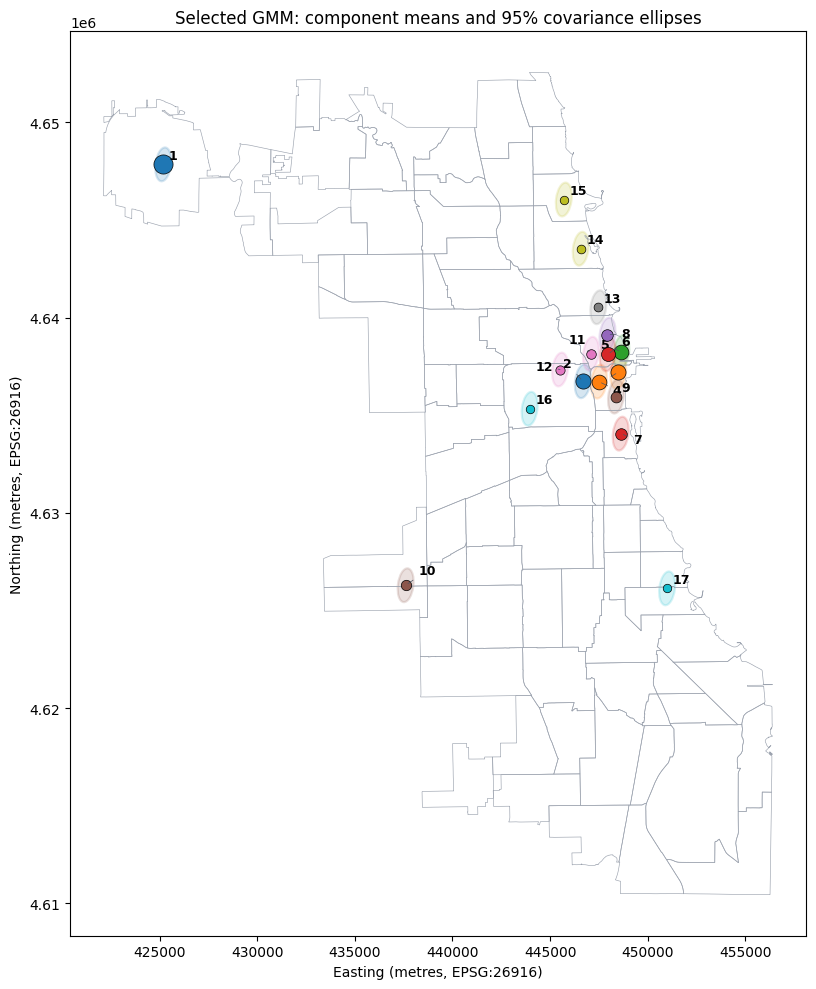

In [18]:
fig, ax = plt.subplots(figsize=(9, 10))
community_areas.boundary.plot(ax=ax, color="#9ca3af", linewidth=0.45)
colors = plt.cm.tab10(np.linspace(0, 1, len(component_table)))
component_label_offsets = {
    2: (-14, 10), 3: (-15, -10), 4: (10, -9), 5: (-15, 3),
    6: (10, 7), 7: (9, -7), 8: (10, -2), 10: (9, 8),
    11: (-16, 8), 12: (-18, 0),
}

for row, color in zip(component_table.itertuples(), colors):
    ellipse = Ellipse(
        xy=(row.mean_x_km * 1_000, row.mean_y_km * 1_000),
        width=2 * np.sqrt(CHI2_95_DF2) * row.major_std_km * 1_000,
        height=2 * np.sqrt(CHI2_95_DF2) * row.minor_std_km * 1_000,
        angle=row.angle_deg,
        facecolor=color,
        edgecolor=color,
        alpha=0.18,
        linewidth=1.6,
    )
    ax.add_patch(ellipse)
    ax.scatter(
        row.mean_x_km * 1_000, row.mean_y_km * 1_000,
        s=35 + 700 * row.weight, color=color, edgecolor="black", linewidth=0.5, zorder=3,
    )
    label_offset = component_label_offsets.get(row.component, (4, 4))
    ax.annotate(
        str(row.component),
        (row.mean_x_km * 1_000, row.mean_y_km * 1_000),
        xytext=label_offset, textcoords="offset points", fontsize=9, weight="bold",
        arrowprops={"arrowstyle": "-", "color": "#4b5563", "linewidth": 0.5}
        if label_offset != (4, 4) else None,
    )

ax.set_title("Selected GMM: component means and 95% covariance ellipses")
ax.set_xlabel("Easting (metres, EPSG:26916)")
ax.set_ylabel("Northing (metres, EPSG:26916)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Overall GMM density and hot-spot map

The hot-spot surface is the weighted sum of all components, evaluated on a 200 m grid. The map shows probability density per km² within Chicago. Values below 0.1% of the citywide peak are hidden to keep the logarithmic colour scale readable; peak calculations still use the full surface. Density outside Chicago is neither shown nor renormalized.

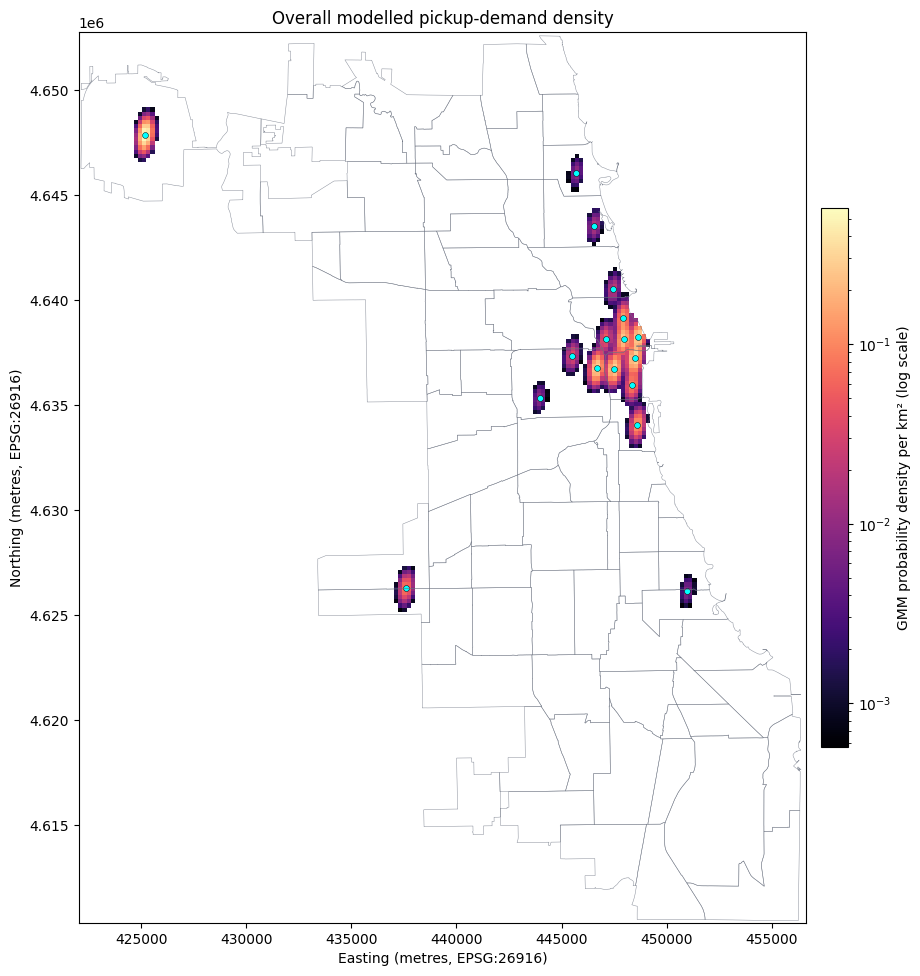

In [19]:
GRID_STEP_KM = 0.2
community_union = community_areas.geometry.union_all()
min_x_m, min_y_m, max_x_m, max_y_m = community_areas.total_bounds
grid_x_km = np.arange(min_x_m / 1_000, max_x_m / 1_000 + GRID_STEP_KM, GRID_STEP_KM)
grid_y_km = np.arange(min_y_m / 1_000, max_y_m / 1_000 + GRID_STEP_KM, GRID_STEP_KM)
grid_xx_km, grid_yy_km = np.meshgrid(grid_x_km, grid_y_km)
grid_coordinates_km = np.column_stack([grid_xx_km.ravel(), grid_yy_km.ravel()])
inside_chicago = contains_xy(
    community_union,
    grid_coordinates_km[:, 0] * 1_000,
    grid_coordinates_km[:, 1] * 1_000,
)

overall_density_flat = np.exp(selected_gmm.score_samples(grid_coordinates_km))
overall_density_flat[~inside_chicago] = np.nan
overall_density = overall_density_flat.reshape(grid_xx_km.shape)
overall_density_max = np.nanmax(overall_density_flat)
overall_display_min = overall_density_max * 1e-3
overall_density_display = np.where(
    overall_density >= overall_display_min,
    overall_density,
    np.nan,
)
overall_norm = LogNorm(
    vmin=overall_display_min,
    vmax=overall_density_max,
)

fig, ax = plt.subplots(figsize=(9, 10))
density_mesh = ax.pcolormesh(
    grid_xx_km * 1_000, grid_yy_km * 1_000, overall_density_display,
    shading="auto", cmap="magma", norm=overall_norm, rasterized=True,
)
community_areas.boundary.plot(ax=ax, color="#6b7280", linewidth=0.35, alpha=0.8)
for row in component_table.itertuples():
    ax.scatter(row.mean_x_km * 1_000, row.mean_y_km * 1_000, s=18, color="cyan", edgecolor="black", linewidth=0.35)

colorbar = fig.colorbar(density_mesh, ax=ax, fraction=0.035, pad=0.02)
colorbar.set_label("GMM probability density per km² (log scale)")
ax.set_title("Overall modelled pickup-demand density")
ax.set_xlabel("Easting (metres, EPSG:26916)")
ax.set_ylabel("Northing (metres, EPSG:26916)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [20]:
overall_peak_flat_index = int(np.nanargmax(overall_density_flat))
overall_peak_point = gpd.GeoDataFrame(
    {"peak_density_per_km2": [overall_density_flat[overall_peak_flat_index]]},
    geometry=[Point(
        grid_coordinates_km[overall_peak_flat_index, 0] * 1_000,
        grid_coordinates_km[overall_peak_flat_index, 1] * 1_000,
    )],
    crs=METRIC_CRS,
)
overall_peak_summary = gpd.sjoin(
    overall_peak_point,
    community_areas[["COMMUNITY", "geometry"]],
    how="left", predicate="within",
).rename(columns={"COMMUNITY": "community_area"})
overall_peak_summary[["community_area", "peak_density_per_km2"]]

,community_area,peak_density_per_km2
0,OHARE,0.573


## Comparison with Community Area totals

The Community Area map sums all 6,049,435 eligible trips by administrative area. The GMM map is based on the reservoir sample from this same population, so differences between the panels come from the spatial method rather than different trip coverage.

Area totals answer where demand is highest by Community Area. The GMM can additionally separate several modes within an area and is not constrained by administrative borders. The table counts component means inside each area only as a geographic description; components overlap and extend beyond these polygons.

In [21]:
community_baseline = community_areas.copy()
community_baseline["community_area"] = pd.to_numeric(
    community_baseline["AREA_NUMBE"]
).astype("int64")
community_baseline = community_baseline.merge(
    community_population_comparison[[
        "community_area", "eligible_trips", "eligible_trip_share",
    ]],
    on="community_area",
    how="left",
    validate="one_to_one",
)
community_baseline[["eligible_trips", "eligible_trip_share"]] = (
    community_baseline[["eligible_trips", "eligible_trip_share"]].fillna(0)
)
community_baseline["eligible_trips"] = community_baseline["eligible_trips"].astype("int64")
community_baseline["eligible_trip_share_pct"] = 100 * community_baseline["eligible_trip_share"]

component_means_by_community = (
    component_table
    .groupby("community_area_at_mean", as_index=False)
    .agg(
        gmm_component_means=("component", "size"),
        weight_of_components_with_mean_inside=("weight", "sum"),
    )
    .rename(columns={"community_area_at_mean": "COMMUNITY"})
)

administrative_gmm_comparison = (
    community_baseline[[
        "community_area", "COMMUNITY", "eligible_trips", "eligible_trip_share_pct",
    ]]
    .merge(component_means_by_community, on="COMMUNITY", how="left")
    .fillna({
        "gmm_component_means": 0,
        "weight_of_components_with_mean_inside": 0,
    })
    .sort_values("eligible_trips", ascending=False)
    .reset_index(drop=True)
)
administrative_gmm_comparison["gmm_component_means"] = (
    administrative_gmm_comparison["gmm_component_means"].astype("int64")
)
administrative_gmm_comparison["component_weight_pct_posthoc"] = (
    100 * administrative_gmm_comparison["weight_of_components_with_mean_inside"]
)

assert community_baseline["eligible_trips"].sum() == gmm_population_trips
assert np.isclose(community_baseline["eligible_trip_share"].sum(), 1)
assert administrative_gmm_comparison["gmm_component_means"].sum() == selected_gmm.n_components

administrative_gmm_comparison[[
    "community_area", "COMMUNITY", "eligible_trips", "eligible_trip_share_pct",
    "gmm_component_means", "component_weight_pct_posthoc",
]].head(12)

,community_area,COMMUNITY,eligible_trips,eligible_trip_share_pct,gmm_component_means,component_weight_pct_posthoc
0,8,NEAR NORTH SIDE,1720160,28.435,4,27.271
1,32,LOOP,1567701,25.915,3,26.801
2,76,OHARE,1344720,22.229,1,22.086
3,28,NEAR WEST SIDE,823553,13.614,3,13.772
4,33,NEAR SOUTH SIDE,295541,4.885,1,4.960
5,56,GARFIELD RIDGE,179872,2.973,1,3.009
6,6,LAKE VIEW,38056,0.629,1,0.633
7,7,LINCOLN PARK,30081,0.497,1,0.776
8,3,UPTOWN,15821,0.262,1,0.377
9,41,HYDE PARK,13854,0.229,0,0.000


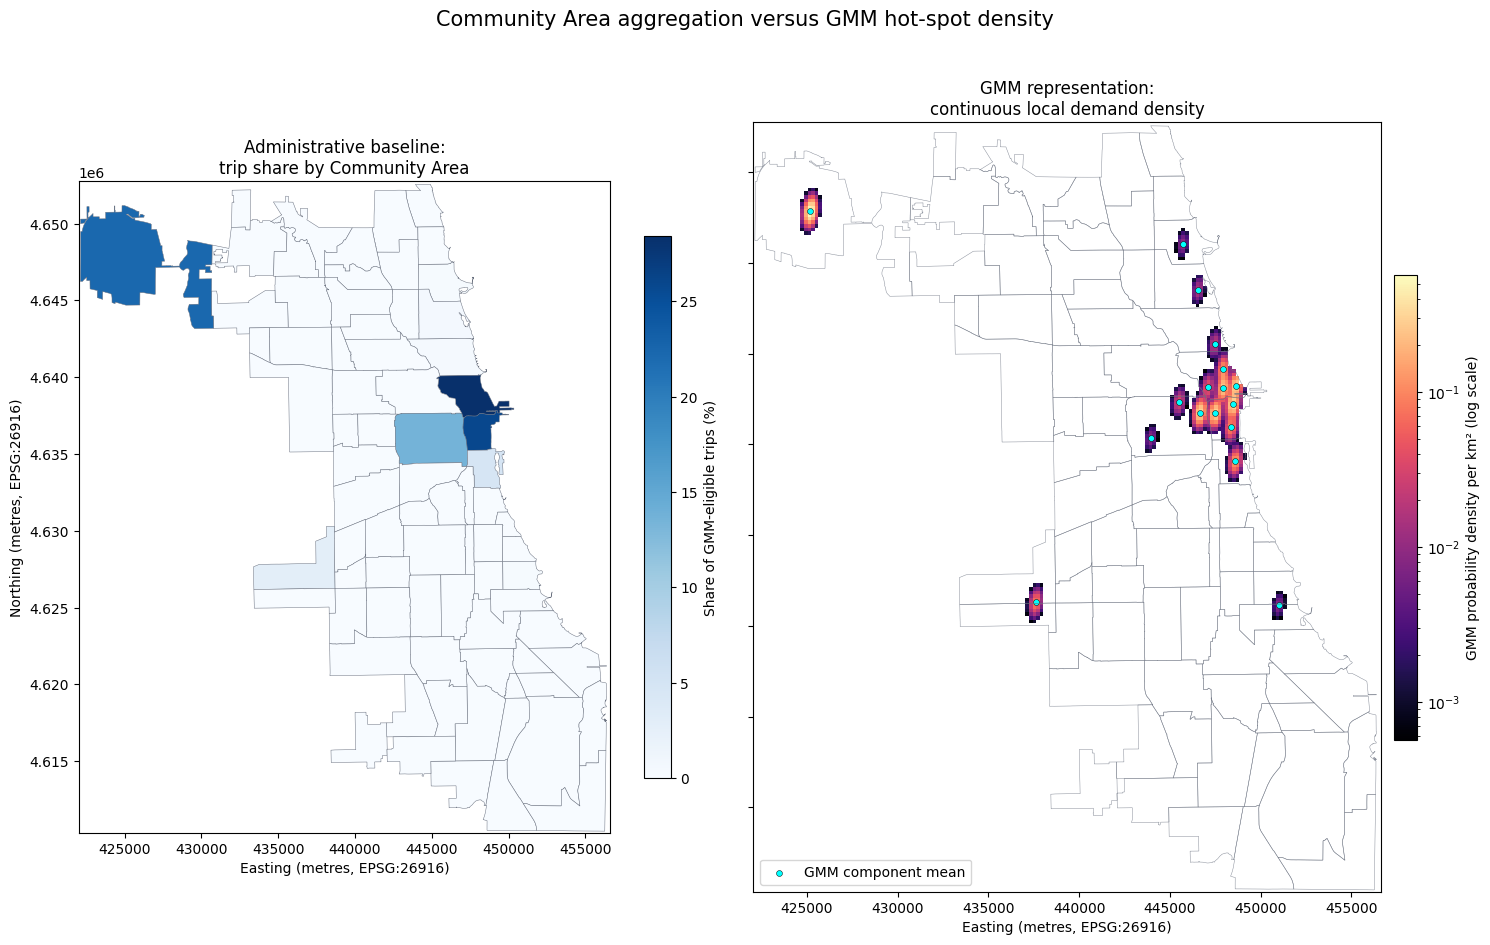

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), sharex=True, sharey=True)

community_baseline.plot(
    ax=axes[0],
    column="eligible_trip_share_pct",
    cmap="Blues",
    edgecolor="#6b7280",
    linewidth=0.35,
    legend=True,
    legend_kwds={
        "label": "Share of GMM-eligible trips (%)",
        "shrink": 0.58,
    },
)
axes[0].set_title("Administrative baseline:\ntrip share by Community Area")

comparison_mesh = axes[1].pcolormesh(
    grid_xx_km * 1_000,
    grid_yy_km * 1_000,
    overall_density_display,
    shading="auto",
    cmap="magma",
    norm=overall_norm,
    rasterized=True,
)
community_areas.boundary.plot(
    ax=axes[1], color="#6b7280", linewidth=0.35, alpha=0.8,
)
axes[1].scatter(
    component_table["mean_x_km"] * 1_000,
    component_table["mean_y_km"] * 1_000,
    s=18,
    color="cyan",
    edgecolor="black",
    linewidth=0.35,
    label="GMM component mean",
)
gmm_colorbar = fig.colorbar(
    comparison_mesh, ax=axes[1], fraction=0.035, pad=0.02,
)
gmm_colorbar.set_label("GMM probability density per km² (log scale)")
axes[1].set_title("GMM representation:\ncontinuous local demand density")
axes[1].legend(loc="lower left")

for ax in axes:
    ax.set_xlabel("Easting (metres, EPSG:26916)")
    ax.set_aspect("equal")
axes[0].set_ylabel("Northing (metres, EPSG:26916)")
fig.suptitle("Community Area aggregation versus GMM hot-spot density", fontsize=15)
plt.tight_layout()
plt.show()

Near North Side accounts for 28.4% of eligible trips, the Loop for 25.9%, O'Hare for 22.2%, and Near West Side for 13.6%. Together, these four areas represent 90.2%. The GMM places four component means in Near North Side, three in the Loop, one in O'Hare, and three in Near West Side. It confirms the same broad geography while separating several modes within the central high-demand areas.

For Community Area totals, the choropleth is the more direct result. The GMM adds detail only through its within-area and cross-boundary modes. Since the input locations are Census centroids, this detail does not support street-level interpretation.

## Compare four equal temporal windows

The day is split into four six-hour windows. Each window is fitted with the selected structure (`tied`, K=17), using its own K-Means initialization and five starts. A 50 m covariance floor reduces collapse at repeated centroids in the smaller subsets.

All panels show joint demand density, `P(time window) × p(location | time window)`, on the same logarithmic scale. They include both the spatial distribution within a window and that window's share of sampled trips. Values below 0.1% of the largest joint peak are hidden.

In [23]:
TIME_WINDOWS = [
    ("Night (00–06)", 0, 6),
    ("Morning (06–12)", 6, 12),
    ("Afternoon (12–18)", 12, 18),
    ("Evening (18–24)", 18, 24),
]
TEMPORAL_REG_COVAR = SPATIAL_MIN_STD_KM ** 2
pickup_hours = pickup_gdf["trip_start_timestamp"].dt.hour
temporal_models = {}
temporal_density_surfaces = {}
temporal_records = []

for window_name, start_hour, end_hour in TIME_WINDOWS:
    window_mask = pickup_hours.between(start_hour, end_hour - 1)
    X_window = pickup_gdf.loc[window_mask, ["pickup_x_km", "pickup_y_km"]].to_numpy()
    window_share = len(X_window) / len(X_gmm)

    temporal_model = GaussianMixture(
        n_components=selected_gmm.n_components,
        covariance_type=selected_gmm.covariance_type,
        init_params="kmeans",
        n_init=GMM_N_INIT,
        max_iter=GMM_MAX_ITER,
        tol=GMM_TOL,
        reg_covar=TEMPORAL_REG_COVAR,
        random_state=RANDOM_SEED,
    ).fit(X_window)
    temporal_models[window_name] = temporal_model

    joint_density_flat = window_share * np.exp(temporal_model.score_samples(grid_coordinates_km))
    joint_density_flat[~inside_chicago] = np.nan
    temporal_density_surfaces[window_name] = joint_density_flat.reshape(grid_xx_km.shape)
    peak_index = int(np.nanargmax(joint_density_flat))

    temporal_covariances = covariance_matrices(temporal_model)
    temporal_min_std = np.sqrt(np.linalg.eigvalsh(temporal_covariances).min())
    temporal_records.append({
        "time_window": window_name,
        "sampled_trips": len(X_window),
        "share_of_all_sampled_trips": window_share,
        "converged": temporal_model.converged_,
        "n_iter": temporal_model.n_iter_,
        "minimum_component_std_km": temporal_min_std,
        "largest_component_weight": temporal_model.weights_.max(),
        "peak_x_km": grid_coordinates_km[peak_index, 0],
        "peak_y_km": grid_coordinates_km[peak_index, 1],
        "peak_joint_density_per_km2": joint_density_flat[peak_index],
    })

temporal_summary = pd.DataFrame(temporal_records)
temporal_peak_points = gpd.GeoDataFrame(
    temporal_summary.copy(),
    geometry=gpd.points_from_xy(
        temporal_summary["peak_x_km"] * 1_000,
        temporal_summary["peak_y_km"] * 1_000,
    ),
    crs=METRIC_CRS,
)
temporal_peak_points = gpd.sjoin(
    temporal_peak_points,
    community_areas[["COMMUNITY", "geometry"]],
    how="left", predicate="within",
).drop_duplicates(subset="time_window")
temporal_summary = (
    temporal_summary
    .merge(temporal_peak_points[["time_window", "COMMUNITY"]], on="time_window", how="left")
    .rename(columns={"COMMUNITY": "peak_community_area"})
)
temporal_summary

,time_window,sampled_trips,share_of_all_sampled_trips,converged,n_iter,minimum_component_std_km,largest_component_weight,peak_x_km,peak_y_km,peak_joint_density_per_km2,peak_community_area
0,Night (00–06),2614,0.010,True,4,0.094,0.536,425.131,"4,647.845",0.048,OHARE
1,Morning (06–12),75690,0.303,True,24,0.164,0.226,446.731,"4,636.845",0.156,NEAR WEST SIDE
2,Afternoon (12–18),113328,0.453,True,22,0.134,0.211,425.131,"4,647.845",0.257,OHARE
3,Evening (18–24),58368,0.233,True,2,0.173,0.324,425.131,"4,647.845",0.327,OHARE


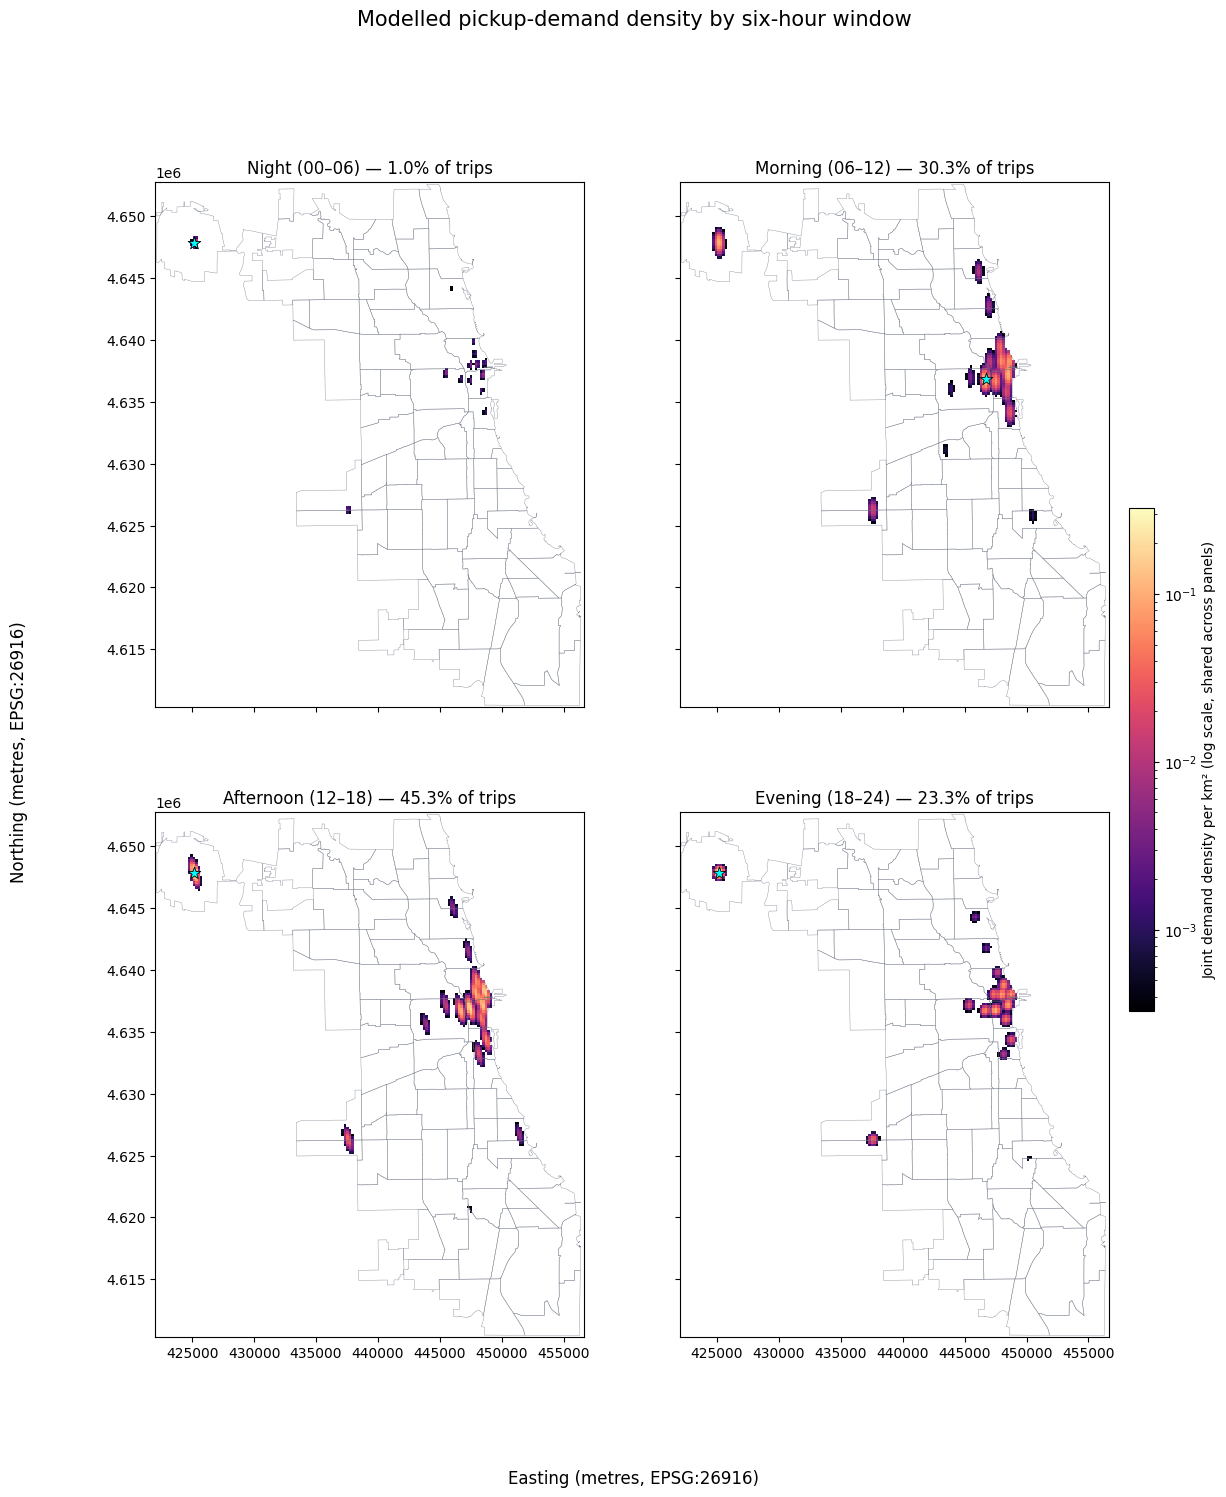

In [24]:
temporal_density_max = max(
    np.nanmax(surface) for surface in temporal_density_surfaces.values()
)
temporal_display_min = temporal_density_max * 1e-3
temporal_norm = LogNorm(
    vmin=temporal_display_min,
    vmax=temporal_density_max,
)

fig, axes = plt.subplots(2, 2, figsize=(13, 15), sharex=True, sharey=True)
last_mesh = None
for ax, (window_name, _, _) in zip(axes.ravel(), TIME_WINDOWS):
    surface = temporal_density_surfaces[window_name]
    surface_display = np.where(surface >= temporal_display_min, surface, np.nan)
    last_mesh = ax.pcolormesh(
        grid_xx_km * 1_000, grid_yy_km * 1_000, surface_display,
        shading="auto", cmap="magma", norm=temporal_norm, rasterized=True,
    )
    community_areas.boundary.plot(ax=ax, color="#6b7280", linewidth=0.3, alpha=0.8)
    peak_row = temporal_summary.loc[temporal_summary["time_window"] == window_name].iloc[0]
    ax.scatter(peak_row["peak_x_km"] * 1_000, peak_row["peak_y_km"] * 1_000, marker="*", s=90, color="cyan", edgecolor="black", linewidth=0.6)
    ax.set_title(f"{window_name} — {peak_row['share_of_all_sampled_trips']:.1%} of trips")
    ax.set_aspect("equal")

fig.supxlabel("Easting (metres, EPSG:26916)")
fig.supylabel("Northing (metres, EPSG:26916)")
colorbar = fig.colorbar(last_mesh, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
colorbar.set_label("Joint demand density per km² (log scale, shared across panels)")
fig.suptitle("Modelled pickup-demand density by six-hour window", y=0.995, fontsize=15)
plt.show()

## Results and limitations

Of the 13,386,706 cleaned trips, 6,049,435 have Census-based pickup centroids and are eligible for the GMM. The fit uses a fixed sample of 250,000 trips and projected pickup coordinates only. Models with K=2–30 and four covariance specifications are compared using BIC, convergence, minimum spatial spread and component weight. Community Areas are used for maps, labels and the area-level comparison, but not as model features.

### Results

The selected model has tied covariance and K=17. Its largest component is located in O'Hare and accounts for 22.1% of sampled demand. Other large components lie in Near West Side (12.1%), the Loop (11.9% and 11.2%), and Near North Side (11.1% and 9.4%). Several component means can fall in the same Community Area because the labels are assigned after fitting.

All components share a major standard deviation of 0.356 km, a minor standard deviation of 0.162 km and a 95% ellipse area of 1.085 km². Their peak densities therefore differ through component weight. Both the highest component peak (0.610 per km²) and the maximum of the summed density surface (0.573 per km²) are in O'Hare. Other modes appear around the Loop, Near West Side, Near North Side, Near South Side and Garfield Ridge.

The Community Area totals show the same broad pattern. Near North Side, the Loop, O'Hare and Near West Side contain 90.2% of eligible demand. The GMM mainly adds a subdivision of the central areas: four component means lie in Near North Side, three in the Loop and three in Near West Side, compared with one in O'Hare. For area totals alone, the Community Area aggregation remains the simpler result.

Night, morning, afternoon and evening contain 1.0%, 30.3%, 45.3% and 23.3% of the sample, respectively. All four temporal models converge above the 50 m covariance floor. The density maximum is in O'Hare at night, afternoon and evening, and in Near West Side during the morning. Evening demand has the highest joint peak despite fewer trips than the afternoon, indicating stronger spatial concentration. Possible links to airport schedules or commuting remain interpretations rather than causal findings.

### Interpretation rules

Component weights refer to the eligible sample, not all cleaned trips. Under tied covariance, all components have the same ellipse shape, so a larger weight also produces a higher component peak. Components overlap and have no hard boundary. Community Area names only locate component means or grid maxima, they do not define the model.

### Limitations

- Only 45.19% of cleaned trips have Census-based pickup centroids. Their Community Area distribution differs from the full population by 20.48% in total variation, with a maximum difference of 9.27 percentage points.
- The eligible data contain 469 distinct published centroids. Repeated observations measure demand at these locations but add no street-level precision.
- The raw BIC winner is not usable: 23 of its components are narrower than 50 m, 22 reach the numerical floor, and its smallest component is below 0.25% weight.
- Tied covariance prevents individual component collapse but gives all components the same shape. K=17 also depends on the 50 m and 0.25% thresholds; K=18 already fails the weight criterion.
- Rare centroids can be missing from the reservoir sample.
- Gaussian tails extend beyond Chicago. The maps hide these values without boundary correction or renormalization.
- Components are density terms, not administrative areas, routes or neighbourhood definitions.
- The four temporal models use the same structure for comparison rather than selecting K separately for each window.
- The analysis identifies spatial concentrations, not their causes.